# 대학원 합격 예측 데이터셋 — 선형회귀 & 이진 분류 연습

데이터셋: `admission_predict.csv` (400행)

| 컬럼 | 타입 | 범위 | 설명 |
|---|---|---|---|
| Serial No. | int | 1~500 | 학생 식별 번호 |
| GRE Score | int | 290~340 | 미국 대학원 입학시험 점수 |
| TOEFL Score | int | 92~120 | 공인 영어 능력 점수 |
| University Rating | int | 1~5 | 지원/출신 대학 명성 레벨 |
| SOP | float | 1.0~5.0 | 자기소개서/학업계획서 점수 |
| LOR | float | 1.0~5.0 | 교수 추천서 점수 |
| CGPA | float | 6.80~9.92 | 학부 평균 학점 (10점 만점) |
| Research | int | 0/1 | 학부 연구 참여 경험 |
| Chance of Admit | int | 0/1 | 합격 1, 불합격 0 |

---

## 목차

| 장 | 주제 | 과제 유형 |
|---|---|---|
| 0 | 환경 설정 · 데이터 로드 · 공통 전처리 | — |
| 1 | CGPA 예측 | 다중선형회귀 |
| 2 | GRE Score 예측 (단순 → 다중) | 선형회귀 |
| 3 | 상관계수 히트맵 & 다중공선성(VIF) | 진단 |
| 4 | 스케일러 비교 (원본 / MinMax / Standard) | 이진 분류 |
| 5 | Research 예측 | 이진 분류 |

### 이 데이터셋의 중요한 제약

원본 Kaggle 데이터셋은 `Chance of Admit`이 **0.34~0.97 실수값**이라 선형회귀 타깃으로 쓰는 게 정석입니다.
하지만 이 파일은 그 값을 **0/1로 이진화한 버전**이라 연속형 타깃이 없습니다.

그래서 이 노트북은 선형회귀 타깃을 `CGPA`(1장)와 `GRE Score`(2장)로 잡고,
이진 분류는 `Chance of Admit`(4장)과 `Research`(5장)로 연습합니다.

---
## 0. 환경 설정 · 데이터 로드 · 공통 전처리

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
)

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':          # Mac OS
    plt.rc('font', family='AppleGothic')
else:                                        # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')
pd.set_option('display.width', 120)

RANDOM_STATE = 42   # 재현성을 위해 전 장에서 동일하게 사용

In [2]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"admission_predict.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0


### 0-1. 전처리

두 가지만 처리합니다.

1. **컬럼명 공백 제거** — 원본 Kaggle 데이터는 `'LOR '`, `'Chance of Admit '`처럼 이름 끝에 공백이 붙어 있습니다.
   눈에 보이지 않아서 `KeyError`의 단골 원인이 되니 먼저 정리합니다.
2. **식별자 컬럼 제거** — `Unnamed: 0`, `Serial No.`는 학생 번호일 뿐 예측에 쓸 정보가 없습니다.
   그대로 넣으면 모델이 "번호가 크면 합격" 같은 엉뚱한 패턴을 학습할 수 있습니다.

In [3]:
print("정리 전:", list(df.columns))

df.columns = df.columns.str.strip()
print("정리 후:", list(df.columns))

data = df.drop(columns=['Unnamed: 0', 'Serial No.'], errors='ignore')

print("\nshape:", data.shape)
print("\n결측치:")
print(data.isna().sum())
data.head()

정리 전: ['Unnamed: 0', 'Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']
정리 후: ['Unnamed: 0', 'Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

shape: (400, 8)

결측치:
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0


In [4]:
# 타깃 분포 & 기술통계 확인
print("Chance of Admit 분포:")
print(data['Chance of Admit'].value_counts().sort_index())
print(data['Chance of Admit'].value_counts(normalize=True).sort_index().round(3))

data.describe().round(3)

Chance of Admit 분포:
Chance of Admit
0    220
1    180
Name: count, dtype: int64
Chance of Admit
0    0.55
1    0.45
Name: proportion, dtype: float64


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000,400.00,400.000,400.000,400.000,400.000,400.000,400.000
mean,316.808,107.41,3.088,3.400,3.452,8.599,0.548,0.450
std,11.474,6.07,1.144,1.007,0.898,0.596,0.498,0.498
min,290.000,92.00,1.000,1.000,1.000,6.800,0.000,0.000
25%,308.000,103.00,2.000,2.500,3.000,8.170,0.000,0.000
50%,317.000,107.00,3.000,3.500,3.500,8.610,1.000,0.000
75%,325.000,112.00,4.000,4.000,4.000,9.062,1.000,1.000
max,340.000,120.00,5.000,5.000,5.000,9.920,1.000,1.000


> **체크포인트**: 합격/불합격 비율이 대략 45:55 정도로 나옵니다.
> 한쪽이 90% 이상인 **불균형 데이터가 아니므로** accuracy를 주요 지표로 써도 무리가 없습니다.
> (불균형이 심하면 accuracy는 "전부 다수 클래스로 찍기"만 해도 높게 나와서 의미가 없어집니다.)

---
## 1. CGPA 예측 — 다중선형회귀

**타깃**: `CGPA` (6.80~9.92 연속값)
**피처**: GRE, TOEFL, University Rating, SOP, LOR, Research

`Chance of Admit`은 **피처에서 제외**합니다. 합격 여부는 학점의 *결과* 쪽에 가까운 변수라서,
이걸 입력으로 넣으면 "결과로 원인을 예측하는" 구조가 됩니다.
실제 서비스 시점에는 아직 모르는 값을 쓰는 셈이라 데이터 누수(leakage)에 해당합니다.

In [5]:
X = data.drop(columns=['CGPA', 'Chance of Admit'])
y = data['CGPA']

print("피처:", list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"train {X_train.shape} / test {X_test.shape}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # train은 fit_transform
X_test_s  = scaler.transform(X_test)        # test는 transform만 (train 기준 적용)

피처: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'Research']
train (320, 6) / test (80, 6)


> **주의**: 스케일러는 **train에만 `fit`** 하고 test에는 `transform`만 적용합니다.
> test 데이터로 `fit`하면 시험 문제의 평균·표준편차를 미리 훔쳐보는 것과 같습니다.

In [6]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred = lr.predict(X_test_s)

print(f"R²   : {r2_score(y_test, pred):.4f}")
print(f"RMSE : {mean_squared_error(y_test, pred) ** 0.5:.4f}")
print(f"MAE  : {mean_absolute_error(y_test, pred):.4f}")
print(f"\n절편 : {lr.intercept_:.4f}")

R²   : 0.7974
RMSE : 0.2811
MAE  : 0.2254

절편 : 8.5878


GRE Score            0.2335
TOEFL Score          0.1460
LOR                  0.0953
University Rating    0.0875
SOP                  0.0545
Research            -0.0138
dtype: float64


C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph

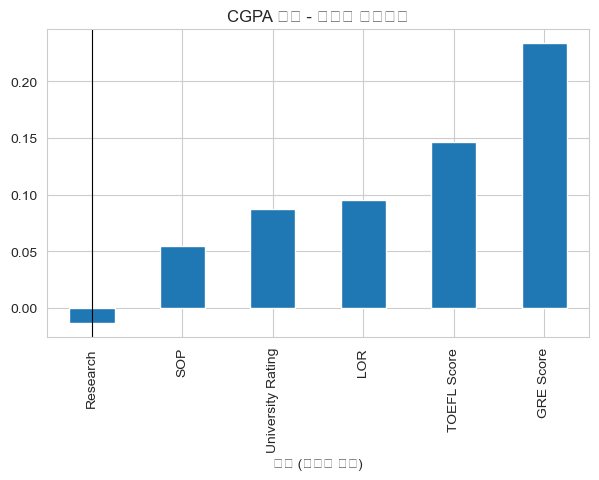

In [16]:
# 표준화된 계수 → 변수 간 중요도를 직접 비교할 수 있다
coef = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coef.round(4))

plt.figure(figsize=(7, 4))
coef.sort_values().plot(kind='bar')
plt.axvline(0, color='k', lw=0.8)
plt.title('CGPA 예측 - 표준화 회귀계수')
plt.xlabel('계수 (표준화 기준)')
# plt.tight_layout()
plt.show()

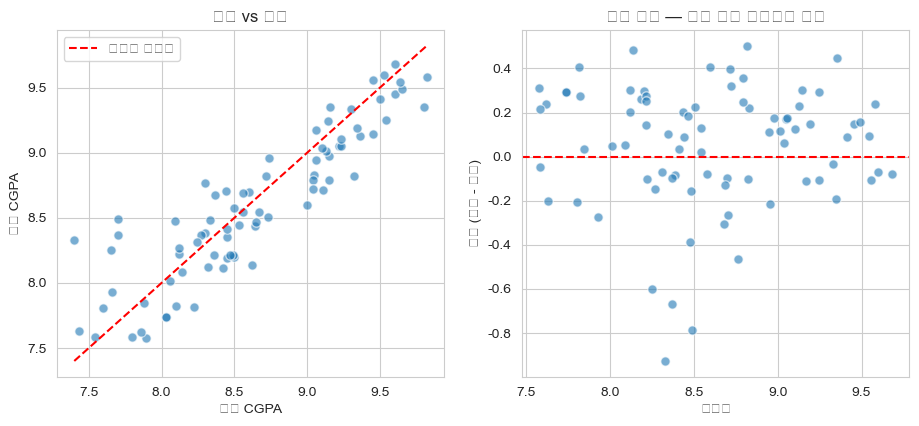

In [18]:
# 실제 vs 예측 / 잔차 플롯
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_test, pred, alpha=0.6, edgecolor='w', s=45)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='완벽한 예측선')
axes[0].set_xlabel('실제 CGPA'); axes[0].set_ylabel('예측 CGPA')
axes[0].set_title('실제 vs 예측')
axes[0].legend()

resid = y_test - pred
axes[1].scatter(pred, resid, alpha=0.6, edgecolor='w', s=45)
axes[1].axhline(0, color='r', ls='--', lw=1.5)
axes[1].set_xlabel('예측값'); axes[1].set_ylabel('잔차 (실제 - 예측)')
axes[1].set_title('잔차 플롯 — 패턴 없이 흩어져야 정상')

# plt.tight_layout()
plt.show()

### 1-1. 확인 실습 — 스케일링은 선형회귀 성능을 바꾸지 않는다

선형회귀(OLS)는 **스케일 불변**입니다. 스케일링을 해도 R²·RMSE가 똑같이 나옵니다.
위에서 StandardScaler를 쓴 이유는 오직 **계수 크기를 서로 비교**하기 위해서입니다.

반면 로지스틱 회귀는 경사하강법 계열로 최적화하기 때문에 스케일링에 민감합니다 → **4장에서 직접 비교**합니다.

In [19]:
lr_raw = LinearRegression().fit(X_train, y_train)      # 스케일링 없이
pred_raw = lr_raw.predict(X_test)

print(f"스케일링 O  R² = {r2_score(y_test, pred):.6f},  RMSE = {mean_squared_error(y_test, pred) ** 0.5:.6f}")
print(f"스케일링 X  R² = {r2_score(y_test, pred_raw):.6f},  RMSE = {mean_squared_error(y_test, pred_raw) ** 0.5:.6f}")
print("\n→ 소수점 6자리까지 동일. 단, 계수의 '단위'는 달라진다:")
print(pd.DataFrame({'표준화 계수': lr.coef_, '원본 단위 계수': lr_raw.coef_}, index=X.columns).round(4))

스케일링 O  R² = 0.797365,  RMSE = 0.281081
스케일링 X  R² = 0.797365,  RMSE = 0.281081

→ 소수점 6자리까지 동일. 단, 계수의 '단위'는 달라진다:
                   표준화 계수  원본 단위 계수
GRE Score          0.2335    0.0207
TOEFL Score        0.1460    0.0243
University Rating  0.0875    0.0764
SOP                0.0545    0.0534
LOR                0.0953    0.1063
Research          -0.0138   -0.0276


> **해석 연습**: 원본 단위 계수에서 `GRE Score`의 값이 작게 나오는 건 영향력이 약해서가 아니라
> **GRE는 1점 단위, Research는 0/1 단위**라서 척도가 다르기 때문입니다.
> 중요도를 비교할 때 표준화 계수를 보는 이유가 바로 이것입니다.

---
## 2. GRE Score 예측 — 단순선형회귀 → 다중선형회귀

변수를 하나만 쓰는 **단순선형회귀**로 시작해서 회귀선을 눈으로 확인하고,
변수를 늘린 **다중선형회귀**와 성능을 비교합니다.

### 2-1. 단순선형회귀 — CGPA 하나로 GRE 예측

In [ ]:
X_s = data[['CGPA']]        # 2차원 유지 필수 (대괄호 2개)
y_g = data['GRE Score']

Xs_tr, Xs_te, yg_tr, yg_te = train_test_split(
    X_s, y_g, test_size=0.2, random_state=RANDOM_STATE
)

slr = LinearRegression().fit(Xs_tr, yg_tr)
pred_s = slr.predict(Xs_te)

print(f"회귀식: GRE Score = {slr.coef_[0]:.3f} x CGPA + {slr.intercept_:.3f}")
print(f"\nR²   : {r2_score(yg_te, pred_s):.4f}")
print(f"RMSE : {mean_squared_error(yg_te, pred_s) ** 0.5:.4f}")
print(f"MAE  : {mean_absolute_error(yg_te, pred_s):.4f}")
print(f"\n해석: CGPA가 1점 오를 때 GRE 점수는 평균 {slr.coef_[0]:.1f}점 오르는 경향")

In [ ]:
plt.figure(figsize=(6.5, 4.8))
plt.scatter(Xs_tr, yg_tr, alpha=0.35, s=40, label='train')
plt.scatter(Xs_te, yg_te, alpha=0.85, s=45, color='orange', edgecolor='w', label='test')

# DataFrame으로 만들어야 "feature names" 경고가 안 뜬다 (fit할 때 DataFrame을 썼으므로)
line_x = pd.DataFrame({'CGPA': np.linspace(data['CGPA'].min(), data['CGPA'].max(), 100)})
plt.plot(line_x['CGPA'], slr.predict(line_x), 'r-', lw=2.2, label='회귀선')

plt.xlabel('CGPA'); plt.ylabel('GRE Score')
plt.title('단순선형회귀: CGPA → GRE Score')
plt.legend()
plt.tight_layout()
plt.show()

### 2-2. 다중선형회귀로 확장

In [ ]:
feats = ['CGPA', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'Research']
X_m = data[feats]

Xm_tr, Xm_te, ygm_tr, ygm_te = train_test_split(
    X_m, y_g, test_size=0.2, random_state=RANDOM_STATE
)

sc_m = StandardScaler()
Xm_tr_s = sc_m.fit_transform(Xm_tr)
Xm_te_s = sc_m.transform(Xm_te)

mlr = LinearRegression().fit(Xm_tr_s, ygm_tr)
pred_m = mlr.predict(Xm_te_s)

compare = pd.DataFrame([
    {'모델': '단순 (CGPA만)',
     'R²': r2_score(yg_te, pred_s),
     'RMSE': mean_squared_error(yg_te, pred_s) ** 0.5,
     'MAE': mean_absolute_error(yg_te, pred_s)},
    {'모델': f'다중 ({len(feats)}개 변수)',
     'R²': r2_score(ygm_te, pred_m),
     'RMSE': mean_squared_error(ygm_te, pred_m) ** 0.5,
     'MAE': mean_absolute_error(ygm_te, pred_m)},
])
print(compare.round(4).to_string(index=False))

print("\n다중회귀 계수 (표준화):")
print(pd.Series(mlr.coef_, index=feats).sort_values(key=abs, ascending=False).round(3))

In [ ]:
# 두 모델을 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

for ax, (p, t, name) in zip(axes, [(pred_s, yg_te, '단순 (CGPA만)'),
                                   (pred_m, ygm_te, '다중 (6개 변수)')]):
    ax.scatter(t, p, alpha=0.65, edgecolor='w', s=45)
    lims = [285, 345]
    ax.plot(lims, lims, 'r--', lw=1.4)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('실제 GRE'); ax.set_ylabel('예측 GRE')
    ax.set_title(f'{name}  |  R² = {r2_score(t, p):.3f}')

plt.tight_layout()
plt.show()

> **체크포인트**: 변수를 1개 → 6개로 늘렸는데 R² 상승폭이 기대보다 작게 나올 겁니다.
> CGPA 하나가 이미 많은 정보를 담고 있고, 추가한 변수들이 **CGPA와 강하게 상관**되어 있어
> 새로운 정보를 거의 보태지 못하기 때문입니다. 이게 바로 다음 3장의 주제입니다.

---
## 3. 상관계수 히트맵 & 다중공선성(VIF)

**다중공선성(multicollinearity)**: 피처들끼리 서로 강하게 상관된 상태.

예측 성능 자체는 괜찮아 보여도, **개별 계수의 부호와 크기를 신뢰할 수 없게** 됩니다.
1~2장에서 계수로 변수 중요도를 해석했는데, 그 해석이 얼마나 안전한지 여기서 검증합니다.

In [ ]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(9, 7.2))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('변수 간 상관계수', pad=12)
plt.tight_layout()
plt.show()

# 상관 0.7 이상인 쌍만 뽑아보기
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack()
             .sort_values(key=abs, ascending=False))
print("상관계수 |r| >= 0.7 인 변수 쌍:")
print(pairs[pairs.abs() >= 0.7].round(3))

In [ ]:
# 각 변수를 나머지 변수로 회귀시켜 VIF = 1 / (1 - R^2) 계산 (statsmodels 없이)
def calc_vif(X: pd.DataFrame) -> pd.Series:
    vifs = {}
    for col in X.columns:
        others = X.drop(columns=[col])
        r2 = LinearRegression().fit(others, X[col]).score(others, X[col])
        vifs[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(vifs).sort_values(ascending=False)


X_all = data.drop(columns=['Chance of Admit'])
vif = calc_vif(X_all)

print("VIF (Variance Inflation Factor)")
print(vif.round(2))
print("\n판단 기준:  VIF > 10 → 심각  |  5~10 → 주의  |  < 5 → 양호")

In [ ]:
plt.figure(figsize=(7, 4))
colors = ['#E45756' if v > 10 else '#F2A93B' if v > 5 else '#4C78A8' for v in vif.sort_values()]
vif.sort_values().plot(kind='barh', color=colors)
plt.axvline(5,  color='#F2A93B', ls='--', lw=1.2, label='주의 (5)')
plt.axvline(10, color='#E45756', ls='--', lw=1.2, label='심각 (10)')
plt.xlabel('VIF')
plt.title('변수별 다중공선성')
plt.legend()
plt.tight_layout()
plt.show()

### 3-1. 실습 — 상관 높은 변수를 빼면 계수가 흔들린다

1장의 CGPA 예측 모델에서 상관이 높은 변수를 하나씩 제거하며 **계수가 얼마나 변하는지** 관찰합니다.
계수가 크게 출렁인다면, 그 계수를 "이 변수의 영향력"으로 해석하는 건 위험하다는 신호입니다.

In [ ]:
# 주의: 여기서는 계수 변화만 비교하는 것이 목적이라 train/test 분리 없이
#       전체 데이터로 적합시킨다. 그래서 R²가 1장의 test R²와 다르게 나온다.
rows = []
for drop_cols in [[], ['GRE Score'], ['GRE Score', 'TOEFL Score']]:
    Xv = X_all.drop(columns=['CGPA'] + drop_cols)
    Xv_s = StandardScaler().fit_transform(Xv)
    m = LinearRegression().fit(Xv_s, data['CGPA'])

    row = {'제외한 변수': ', '.join(drop_cols) if drop_cols else '(없음)',
           'R²': m.score(Xv_s, data['CGPA'])}
    row.update(dict(zip(Xv.columns, m.coef_.round(3))))
    rows.append(row)

result = pd.DataFrame(rows).set_index('제외한 변수')
print(result.round(3).to_string())
print("\n→ 같은 변수의 계수가 행마다 얼마나 변하는지 확인해 보세요.")
print("   많이 변한다 = 다중공선성 때문에 계수 해석을 신뢰하기 어렵다")

> **정리**: 다중공선성이 있을 때 선택지는 세 가지입니다.
> 1. 상관이 높은 변수 중 **하나만 남기기** (가장 단순)
> 2. **Ridge/Lasso** 같은 규제(regularization) 모델 쓰기
> 3. **예측만 목적**이라면 그냥 두기 — 성능에는 큰 해가 없습니다
>
> 즉 다중공선성은 "예측의 문제"가 아니라 **"해석의 문제"** 입니다.

---
## 4. 스케일러 비교 — 합격 예측 이진 분류

원래 과제인 **합격 예측**(`Chance of Admit`)으로 돌아와서,
전처리 방식 세 가지를 로지스틱 회귀에 각각 적용해 비교합니다.

- 스케일링 없음 (원본)
- `MinMaxScaler` — 0~1 범위로 압축
- `StandardScaler` — 평균 0, 표준편차 1

**정확도만 보지 말고 `수렴 반복횟수`(`n_iter_`) 컬럼을 꼭 보세요.** 핵심 포인트가 거기에 있습니다.

In [ ]:
X = data.drop(columns=['Chance of Admit'])
y = data['Chance of Admit']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train {X_tr.shape} / test {X_te.shape}")
print("stratify 덕분에 train/test의 합격 비율이 유지됨:")
print(f"  train {y_tr.mean():.3f} / test {y_te.mean():.3f} / 전체 {y.mean():.3f}")

In [ ]:
rows = []
models = {}

for name, sc in [('스케일링 없음', None),
                 ('MinMaxScaler', MinMaxScaler()),
                 ('StandardScaler', StandardScaler())]:
    if sc is None:
        a, b = X_tr.values, X_te.values
    else:
        a, b = sc.fit_transform(X_tr), sc.transform(X_te)

    m = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(a, y_tr)
    p = m.predict(b)
    models[name] = (m, b)

    rows.append({
        '전처리': name,
        'accuracy': accuracy_score(y_te, p),
        'f1': f1_score(y_te, p),
        '수렴 반복횟수': int(m.n_iter_[0]),
    })

scaler_cmp = pd.DataFrame(rows)
print(scaler_cmp.round(4).to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

scaler_cmp.set_index('전처리')[['accuracy', 'f1']].plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('성능 — 차이가 거의 없다')
axes[0].legend(loc='lower right')

scaler_cmp.set_index('전처리')['수렴 반복횟수'].plot(kind='bar', ax=axes[1], rot=15, color='#E45756')
axes[1].set_title('수렴 반복횟수 — 차이가 크다')
axes[1].set_ylabel('n_iter_')

plt.tight_layout()
plt.show()

> **핵심**: 스케일링은 "성능을 올려주는 것"이 아니라 **"최적화를 빠르고 안정적으로 만드는 것"** 입니다.
> 400행짜리 작은 데이터에서는 정확도 차이가 안 보여도 반복횟수는 몇 배씩 벌어집니다.
> 데이터가 커지거나 변수 간 척도 차이가 심해지면 이 차이가 **수렴 실패**로 이어집니다.

In [ ]:
# 극단적 확인: max_iter를 20으로 줄이면 어떤 쪽이 먼저 터지는가
for name, sc in [('스케일링 없음', None), ('StandardScaler', StandardScaler())]:
    a = X_tr.values if sc is None else sc.fit_transform(X_tr)
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        LogisticRegression(max_iter=20).fit(a, y_tr)
        msg = '수렴 실패 경고 발생 ⚠' if len(w) else '정상 수렴 ✅'
    print(f"{name:16s} → {msg}")

### 4-1. StandardScaler 모델 상세 평가 + 임계값 조정

위 표에서 세 전처리의 정확도는 거의 비슷하게 나옵니다(어느 쪽이 1위인지는 데이터와 random_state에 따라 바뀝니다).
여기서는 수렴이 가장 안정적인 `StandardScaler` 모델을 골라 자세히 들여다봅니다.

In [ ]:
best_model, X_te_best = models['StandardScaler']   # 성능 1위가 아니라 '수렴이 안정적인' 모델을 선택
pred_best = best_model.predict(X_te_best)

print(f"Accuracy : {accuracy_score(y_te, pred_best):.4f}")
print(f"F1       : {f1_score(y_te, pred_best):.4f}\n")
print(classification_report(y_te, pred_best, target_names=['불합격(0)', '합격(1)']))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_te_best, y_te,
    display_labels=['불합격', '합격'], cmap='Blues'
)
plt.title('합격 예측 혼동행렬')
plt.tight_layout()
plt.show()

In [ ]:
# 계수 해석 — 어떤 변수가 합격에 가장 크게 작용하는가
coef_clf = pd.Series(best_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print(coef_clf.round(4))

plt.figure(figsize=(7, 4))
s = coef_clf.sort_values()
s.plot(kind='barh', color=np.where(s > 0, '#4C78A8', '#E45756'))
plt.axvline(0, color='k', lw=0.8)
plt.title('합격 예측 - 로지스틱 회귀 계수 (양수 = 합격 확률 ↑)')
plt.tight_layout()
plt.show()

In [ ]:
# 임계값(threshold)을 바꿔가며 precision-recall 트레이드오프 관찰
proba = best_model.predict_proba(X_te_best)[:, 1]

rows = []
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, p, labels=[0, 1]).ravel()
    rows.append({
        'threshold': th,
        'accuracy': accuracy_score(y_te, p),
        'f1': f1_score(y_te, p, zero_division=0),
        'precision': tp / (tp + fp) if (tp + fp) else 0.0,
        'recall': tp / (tp + fn) if (tp + fn) else 0.0,
        '합격 예측 수': int(p.sum()),
    })

th_df = pd.DataFrame(rows)
print(th_df.round(4).to_string(index=False))

plt.figure(figsize=(7, 4.2))
for c, color in [('precision', '#4C78A8'), ('recall', '#E45756'), ('f1', '#54A24B')]:
    plt.plot(th_df['threshold'], th_df[c], 'o-', label=c, color=color)
plt.axvline(0.5, color='gray', ls='--', lw=1, label='기본 임계값 0.5')
plt.xlabel('threshold'); plt.ylabel('score')
plt.title('임계값에 따른 precision / recall 트레이드오프')
plt.legend()
plt.tight_layout()
plt.show()

> **해석 연습**: 임계값을 올리면 "합격"이라고 확신할 때만 합격으로 분류하므로
> **precision은 오르고 recall은 떨어집니다**.
> 어느 쪽이 중요한지는 목적에 따라 다릅니다.
> - 합격 가능성 있는 학생을 놓치면 안 된다 → **recall** 우선 (임계값 ↓)
> - 합격이라고 말했으면 정말 맞아야 한다 → **precision** 우선 (임계값 ↑)

---
## 5. Research 예측 — 두 번째 이진 분류

**타깃**: `Research` (학부 연구 참여 경험 0/1)

4장의 합격 예측보다 **정확도가 눈에 띄게 낮게 나올 것**입니다.
"모델이 잘 안 되는 경우"를 한 번 겪어보는 것이 이 장의 목적이라, 수치가 낮아도 정상입니다.
성적 지표만으로는 연구 경험 여부를 설명하기 어렵기 때문입니다.

In [ ]:
X_r = data.drop(columns=['Research', 'Chance of Admit'])
y_r = data['Research']

print("피처:", list(X_r.columns))
print("\n클래스 분포:")
print(y_r.value_counts().sort_index())
print(y_r.value_counts(normalize=True).sort_index().round(3))

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_r, y_r, test_size=0.2, stratify=y_r, random_state=RANDOM_STATE
)

sc_r = StandardScaler()
Xr_tr_s = sc_r.fit_transform(Xr_tr)
Xr_te_s = sc_r.transform(Xr_te)

In [ ]:
clf_r = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xr_tr_s, yr_tr)
pred_r = clf_r.predict(Xr_te_s)

baseline = max(yr_te.mean(), 1 - yr_te.mean())   # 다수 클래스로만 찍었을 때의 정확도

print(f"Accuracy : {accuracy_score(yr_te, pred_r):.4f}")
print(f"F1       : {f1_score(yr_te, pred_r):.4f}")
print(f"\n기준선(다수 클래스만 찍기) : {baseline:.4f}")
print(f"→ 모델이 기준선을 {'넘었습니다' if accuracy_score(yr_te, pred_r) > baseline else '넘지 못했습니다'}")
print()
print(classification_report(yr_te, pred_r, target_names=['연구경험 없음(0)', '연구경험 있음(1)']))

> **중요한 습관**: 분류 모델 평가는 항상 **기준선(baseline)과 비교**해야 합니다.
> "정확도 70%"는 그 자체로는 좋은지 나쁜지 알 수 없습니다.
> 다수 클래스로만 찍어도 68%가 나오는 데이터라면, 70%는 사실상 아무것도 학습하지 못한 것입니다.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ConfusionMatrixDisplay.from_estimator(
    clf_r, Xr_te_s, yr_te, display_labels=['없음', '있음'],
    cmap='Oranges', ax=axes[0], colorbar=False
)
axes[0].set_title('Research 예측 혼동행렬')

coef_r = pd.Series(clf_r.coef_[0], index=X_r.columns).sort_values()
coef_r.plot(kind='barh', ax=axes[1], color=np.where(coef_r > 0, '#4C78A8', '#E45756'))
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_title('로지스틱 회귀 계수')

plt.tight_layout()
plt.show()

In [ ]:
# 4장(합격 예측)과 5장(Research 예측) 최종 비교
final = pd.DataFrame([
    {'과제': '합격 예측 (Chance of Admit)',
     'accuracy': accuracy_score(y_te, pred_best),
     'f1': f1_score(y_te, pred_best),
     '기준선': max(y_te.mean(), 1 - y_te.mean())},
    {'과제': 'Research 예측',
     'accuracy': accuracy_score(yr_te, pred_r),
     'f1': f1_score(yr_te, pred_r),
     '기준선': baseline},
])
final['기준선 대비'] = final['accuracy'] - final['기준선']
print(final.round(4).to_string(index=False))

---
## 정리

| 장 | 과제 | 주요 교훈 |
|---|---|---|
| 1 | CGPA 다중선형회귀 | 선형회귀는 스케일 불변 — 스케일링은 **계수 비교용** |
| 2 | GRE 단순 → 다중회귀 | 변수를 늘려도 **상관된 변수**는 정보를 보태지 못한다 |
| 3 | 상관 히트맵 & VIF | 다중공선성은 **예측의 문제가 아니라 해석의 문제** |
| 4 | 합격 예측 이진 분류 | 스케일링의 효과는 성능보다 **수렴 속도**에서 드러난다 |
| 5 | Research 이진 분류 | 정확도는 항상 **기준선과 비교**해서 판단한다 |

### 더 해볼 것

- `Ridge` / `Lasso`로 1장을 다시 풀고 계수가 어떻게 줄어드는지 관찰
- `cross_val_score`로 5-fold 교차검증 — 단일 `train_test_split`의 운(random_state) 의존성 확인
- `RocCurveDisplay`로 4장 모델의 ROC 곡선과 AUC 확인
- `DecisionTreeClassifier` / `RandomForestClassifier`와 성능 비교
- **원본 Kaggle 데이터셋**(`Chance of Admit`이 0~1 실수)을 구해서 같은 타깃으로 회귀와 분류를 모두 수행